# 25｜附錄B_混合精度與量化

執行對稱 int8 量化，直接比較原權重、整數碼與反量化誤差。

對應 `slides/25_附錄B_混合精度與量化.md`；從第一格依序執行即可重現投影片中的表格與圖。

## 來源與改編界線

- Aurélien Géron，`handson-mlp/Appendix_B_mixed_precision_and_quantization.ipynb`，固定 commit `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`，參考 Reduced Precision Models、Symmetric Linear Quantization、Dynamic Quantization。

- 本 Notebook 為課堂短實驗：保留核心張量、演算法或評估流程，改用 NumPy／scikit-learn 與小型資料，讓 CPU 能快速重跑。
- 圖表與數值是本檔實際執行結果，不代表原書完整模型成效。原始程式授權與歸屬見 `../NOTICE.md`。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import SEED, setup, savefig, report
setup()
rng = np.random.default_rng(SEED)

## 課堂小實驗

In [2]:
weights = np.array([[-1.20, -0.35, 0.0, 0.42, 1.05], [0.18, -0.77, 0.63, 0.91, -0.12]])
scale = np.max(np.abs(weights)) / 127
q = np.clip(np.round(weights / scale), -127, 127).astype(np.int8)
dequant = q.astype(float) * scale
err = dequant - weights
table = pd.DataFrame({'weight': weights.ravel(), 'int8': q.ravel(),
                      'dequantized': dequant.ravel(), 'error': err.ravel()})
print('scale:', scale, ' max abs error:', np.max(np.abs(err)))
table.round(5)

scale: 0.009448818897637795  max abs error: 0.004645669291338583


,weight,int8,dequantized,error
0,-1.20,-127,-1.20000,0.00000
1,-0.35,-37,-0.34961,0.00039
2,0.00,0,0.00000,0.00000
3,0.42,44,0.41575,-0.00425
4,1.05,111,1.04882,-0.00118
5,0.18,19,0.17953,-0.00047
6,-0.77,-81,-0.76535,0.00465
7,0.63,67,0.63307,0.00307
8,0.91,96,0.90709,-0.00291
9,-0.12,-13,-0.12283,-0.00283


## 執行結果圖

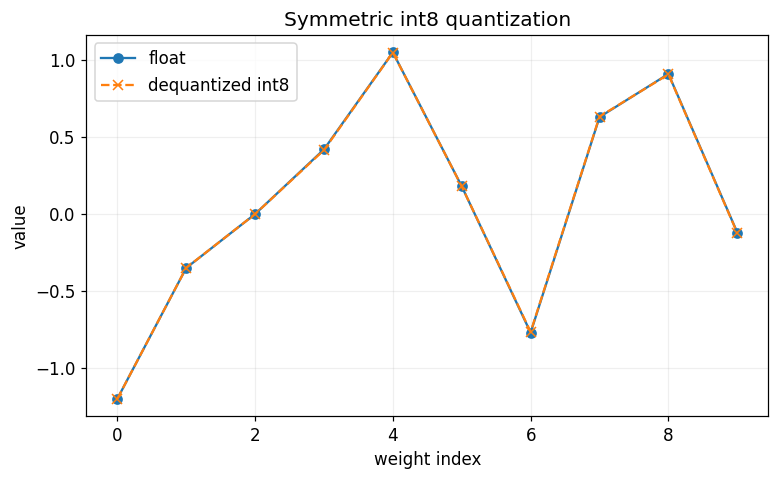

In [3]:
x = np.arange(weights.size)
plt.plot(x, weights.ravel(), 'o-', label='float')
plt.plot(x, dequant.ravel(), 'x--', label='dequantized int8')
plt.xlabel('weight index'); plt.ylabel('value'); plt.title('Symmetric int8 quantization')
plt.legend()
savefig('25_quantization_demo')
report('quantization', {'scale': scale, 'max_abs_error': np.max(np.abs(err)), 'codes': q.tolist()})

## 解讀與延伸

先描述圖或表直接支持的結果，再說明這個縮編實驗不能代表完整模型的哪些面向。